# Step 1.3 — Background Patch Sampling

This notebook samples background tissue patches (fatty vs. fibroglandular) from the preprocessed INbreast mammograms. Mass-bearing regions are excluded from sampling so the background patches never overlap with lesion tissue.

The paper gives a high-level recipe (remove the mass region, sample random-size patches from the rest, separate fatty vs. fibroglandular by thresholding, resize to 224×224) but no implementation specifics. Our replication adds one improvement: **ACR-guided sampling** — we restrict which tissue classes each image may contribute based on its clinical ACR breast-density score, which avoids the mis-labelled patches Otsu thresholding produces at the extremes of the density scale.

**Inputs:**

- `../data/outputs/preprocessed/final/<file>.npy` — preprocessed full images (from Step 1.1).
- `../data/outputs/preprocessed/breast_mask/<file>.npy` — breast region masks.
- `../data/outputs/preprocessed/pect_mask/<file>.npy` — pectoral muscle masks.
- `../data/raw/kaggle_inbreast/AllXML/<file_id>.xml` — XML annotations (for mass exclusion).
- `../data/raw/inbreast/INbreast.xls` — ACR metadata.

**Outputs** (under `../data/outputs/background_patches/`):

- `fatty/<file_id>_fatty_NNN.{npy,png}` — float32 224×224 patches + 8-bit per-patch min-max previews.
- `fibroglandular/<file_id>_fibroglandular_NNN.{npy,png}` — same.
- `patches_index.csv` — per-patch metadata including source file_id, ACR, label, original patch size, bounding box, intensity stats.

**Downstream consumers:** Steps 2.1 (WS), 2.2 (CNN), 2.3 (Fusion) and 2.4 (Scattering Covariance) all read this manifest for the fatty-vs-fibroglandular tissue task. They use the `.npy` patches; the `.png` files are inspection-only.

**Counts produced:** 251 fatty + 183 fibroglandular = **434 background patches** (the paper reports 397). The difference comes mainly from our ACR-guided sampling (see the paper comparison below).


## 1. Setup — imports, paths and RNG

Imports for the whole notebook plus all input and output paths. The five input directories (`DICOM_DIR`, `XLS_PATH`, `XML_DIR`, and the three `PREPROC_*` folders) and the two output folders (`PATCH_BG_FATTY`, `PATCH_BG_FIBRO`) are created on first run if they don't already exist. The single project-wide random generator `RNG = np.random.default_rng(SEED)` (with `SEED = 34`) drives every random patch sampling decision below, so the saved patch set is identical on every run.


**Reproducibility.** All random background-patch sampling is driven by a single NumPy generator `RNG = np.random.default_rng(SEED)` with the project-wide `SEED = 34`, so the generated patch set is identical on every run; the preview grid is seeded with the same value.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import plistlib
from tqdm import tqdm
from PIL import Image
from scipy import ndimage as ndi
from skimage.draw import polygon
from skimage.filters import threshold_otsu

# -----------------------------
# Paths
# -----------------------------
DATA_RAW     = Path("../data/raw")
DATA_OUT     = Path("../data/outputs")

DICOM_DIR    = DATA_RAW / "inbreast" / "ALL-IMGS"
XLS_PATH     = DATA_RAW / "inbreast" / "INbreast.xls"
XML_DIR      = DATA_RAW / "kaggle_inbreast" / "AllXML"

PREPROC_ROOT     = DATA_OUT / "preprocessed"
FINAL_DIR        = PREPROC_ROOT / "final"
BREAST_MASK_DIR  = PREPROC_ROOT / "breast_mask"
PECT_MASK_DIR    = PREPROC_ROOT / "pect_mask"

PATCH_ROOT       = DATA_OUT / "background_patches"
PATCH_BG_FATTY   = PATCH_ROOT / "fatty"
PATCH_BG_FIBRO   = PATCH_ROOT / "fibroglandular"

for p in [PATCH_BG_FATTY, PATCH_BG_FIBRO]:
    p.mkdir(parents=True, exist_ok=True)

SEED = 34  # project-wide seed: drives ALL random patch sampling below
RNG = np.random.default_rng(SEED)

print("XLS exists?", XLS_PATH.exists())
print("FINAL_DIR exists?", FINAL_DIR.exists())
print("XML_DIR exists?", XML_DIR.exists())


XLS exists? True
FINAL_DIR exists? True
XML_DIR exists? True


## 2. Load `INbreast.xls` — per-image ACR density score

The ACR breast-density score (1–4) tells us the clinical breast composition. We use it as a per-image filter for which tissue classes are allowed to contribute (Section 5). The next cell opens `INbreast.xls`, finds the sheet with `File Name + Bi-Rads + ACR + View + Laterality`, drops blank rows, and re-indexes by integer `file_id` so the rest of the notebook can do `image_meta.loc[file_id, "ACR"]` directly.


In [2]:
xls = pd.ExcelFile(XLS_PATH)

def find_sheet_with_cols(required_cols):
    for name in xls.sheet_names:
        df = xls.parse(name)
        cols = {c.strip().lower() for c in df.columns.astype(str)}
        if all(rc.lower() in cols for rc in required_cols):
            return name, df
    return None, None

main_name, main_df = find_sheet_with_cols(["File Name", "Bi-Rads"])
if main_df is None:
    raise ValueError("Couldn't find the main sheet with columns: File Name, Bi-Rads")

main_df = main_df.rename(columns={c: c.strip() for c in main_df.columns})

keep_cols = [c for c in ["File Name", "Bi-Rads", "ACR", "View", "Laterality"] if c in main_df.columns]
main = main_df[keep_cols].copy()
main["file_id"] = pd.to_numeric(main["File Name"], errors="coerce").astype("Int64")

image_meta = main.dropna(subset=["file_id"]).drop_duplicates(subset=["file_id"]).set_index("file_id")
print(f"Unique images with metadata: {len(image_meta)}")
image_meta.head()


Unique images with metadata: 410


,File Name,Bi-Rads,ACR,View,Laterality
file_id,,,,,
22678622,22678622.0,1,4,CC,R
22678646,22678646.0,3,4,CC,L
22678670,22678670.0,1,4,MLO,R
22678694,22678694.0,3,4,MLO,L
22614074,22614074.0,5,2,CC,R


### 2.1 What the XLS metadata gives us

- 410 unique `file_id`s with metadata (matching Step 0.2's audit).
- `ACR` column has 4 values: 1 (almost entirely fatty), 2 (scattered fibroglandular), 3 (heterogeneously dense), 4 (extremely dense). One row has a whitespace-only ACR cell (`file_id 53582540`, a BIRADS-1 normal with no mass — see Step 0.2 §7.1); it's dropped automatically by the `pd.notna()` check in the batch loop in Section 9.

This is the same metadata used by Step 0.2 to derive `tissue_binary` for the tissue task; here we use it directly as the per-image sampling filter.


## 3. XML parser (re-defined for standalone use)

`load_rois_from_inbreast_xml` is re-defined here so this notebook can be run on its own without first running Step 1.2. The function and its `_parse_point_any` / `_coerce_points` helpers are byte-identical to the Step 1.2 versions. They handle the multiple OsiriX `Point_px` formats that show up in different INbreast XMLs (tuple, list, `"(x, y)"` string, etc.).


In [3]:
_num_re = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")

def _parse_point_any(p):
    if isinstance(p, (list, tuple)) and len(p) == 2:
        try:
            return float(p[0]), float(p[1])
        except Exception:
            return None
    if isinstance(p, str):
        nums = _num_re.findall(p)
        if len(nums) >= 2:
            return float(nums[0]), float(nums[1])
    return None


def _coerce_points(pts):
    out = []
    if pts is None:
        return np.zeros((0, 2), dtype=float)
    if isinstance(pts, str):
        nums = _num_re.findall(pts)
        for i in range(0, len(nums) - 1, 2):
            out.append((float(nums[i]), float(nums[i + 1])))
        return np.array(out, dtype=float) if out else np.zeros((0, 2), dtype=float)
    if isinstance(pts, (list, tuple)):
        for p in pts:
            xy = _parse_point_any(p)
            if xy is not None:
                out.append(xy)
            elif isinstance(p, (list, tuple)) and len(p) > 2:
                try:
                    flat = list(p)
                    for i in range(0, len(flat) - 1, 2):
                        out.append((float(flat[i]), float(flat[i + 1])))
                except Exception:
                    pass
    return np.array(out, dtype=float) if out else np.zeros((0, 2), dtype=float)


def load_rois_from_inbreast_xml(xml_path):
    # Return list of ROI dicts with keys 'name' and 'points' (Nx2 x/y).
    with open(xml_path, "rb") as f:
        data = plistlib.load(f)
    img0 = data["Images"][0]
    rois = img0.get("ROIs", [])
    out = []
    for roi in rois:
        name = str(roi.get("Name", "")).strip()
        pts_raw = roi.get("Point_px", None)
        if pts_raw is None:
            pts_raw = roi.get("Points", None)
        pts = _coerce_points(pts_raw)
        if pts.shape[0] < 3:
            continue
        out.append({"name": name, "points": pts})
    return out


## 4. Build `file_id` indices for the preprocessed images

Build four `{int(file_id) → Path}` dicts so the batch loop in Section 9 can do O(1) lookups: one each for the preprocessed `final/`, `breast_mask/`, `pect_mask/` arrays from Step 1.1, plus one for the XML annotations from Step 1.2's source folder. The intersection `final ∩ breast_mask ∩ xml` is the set of eligible images for background sampling — we need all three (an image, the breast region, and the mass polygons to exclude).


In [4]:
def leading_id(name_or_path) -> int:
    stem = Path(name_or_path).stem
    m = re.match(r"^(\d+)", stem)
    if not m:
        raise ValueError(f"Could not extract leading numeric ID from: {name_or_path}")
    return int(m.group(1))


def build_npy_index(folder: Path):
    idx = {}
    for fp in sorted(folder.glob("*.npy")):
        idx[leading_id(fp.name)] = fp
    return idx


def build_xml_index(folder: Path):
    idx = {}
    for fp in sorted(folder.glob("*.xml")):
        if fp.stem.isdigit():
            idx[int(fp.stem)] = fp
    return idx


final_index = build_npy_index(FINAL_DIR)
bmask_index = build_npy_index(BREAST_MASK_DIR)
pmask_index = build_npy_index(PECT_MASK_DIR)
xml_index   = build_xml_index(XML_DIR)

eligible_ids = sorted(set(final_index) & set(bmask_index) & set(xml_index))

print("final npy files      :", len(final_index))
print("breast mask npy files:", len(bmask_index))
print("pect mask npy files  :", len(pmask_index))
print("xml files            :", len(xml_index))
print("eligible image ids   :", len(eligible_ids))


final npy files      : 410
breast mask npy files: 410
pect mask npy files  : 410
xml files            : 343
eligible image ids   : 343


### 4.1 What the index audit shows

- 410 `final/` arrays (from Step 1.1).
- 410 `breast_mask/` arrays (every image has a breast mask, even CC views).
- 410 `pect_mask/` arrays (all-zeros for CC views and for the 4 MLO/ML views without a LabelMe JSON — see Step 0.3 / Step 1.1 §10).
- 343 XML annotation files — the same 67 normal images that have no annotation in Step 0.2 / 1.2 are also missing here.
- **343 eligible image_ids** (the 343-way intersection).

The batch loop in Section 9 iterates over these 343. Of those, only the images that **both** contain a Mass ROI **and** have a usable ACR contribute background patches — roughly 100 distinct file_ids in practice (we still process all 343 to give the loop a chance to enter, but most are filtered before saving).


## 5. The sampler — paper recipe + ACR-guided improvement

The paper gives the high-level recipe but no implementation specifics: remove the mass region, sample random-size patches from the remaining breast area, separate fatty vs. fibroglandular by thresholding, resize patches to 224×224.

Our replication adds one improvement: **ACR-guided sampling**. The ACR density score (1–4) from the XLS tells us the clinical breast composition. Otsu thresholding always forces a binary split regardless of actual tissue composition, which produces mis-labelled patches at the extremes (e.g. labelling lighter fatty tissue as "fibroglandular" inside an ACR-1 breast, where almost everything is fatty by definition). We use ACR to restrict which classes each image is allowed to contribute:

| ACR | Clinical meaning | Sample fatty? | Sample fibroglandular? |
|-----|------------------|---------------|------------------------|
| 1   | Almost entirely fatty       | Yes | No  |
| 2   | Scattered fibroglandular    | Yes | Yes |
| 3   | Heterogeneously dense       | Yes | Yes |
| 4   | Extremely dense             | No  | Yes |

Unlike a fixed-target version, there is no hard-coded target patch count — every eligible image is processed and every patch that passes the quality checks (Section 6) is saved.


## 6. Helpers — mass mask, tissue split, sampler

The next cell defines every per-image helper the batch loop in Section 9 uses:

- **`polygon_to_mask`, `build_mass_mask`, `dilate_mask`** — reconstruct the lesion region from the XML polygons and dilate it by 24 pixels so we never sample background tissue right on the lesion edge.
- **`clean_binary`** — small morphology open/close + drop tiny connected components from a binary mask.
- **`split_fatty_vs_fibro`** — Otsu threshold on the allowed pixels, then exclude an ambiguity band of ±0.03 around the threshold to get cleaner per-class patches.
- **`resize_to_224`, `save_patch_npy_and_png`** — final resize + save (one `.npy` + one preview `.png` per patch).
- **`box_iou`, `boxes_intersect`** — overlap checks; the sampler enforces *no* overlap between accepted patches inside the same image.
- **`sample_one_patch`** — the core sampler. Picks a random patch size, a random centre inside the target mask, checks containment in the allowed region (`require_full_containment=True`), checks target-class fraction (`min_target_frac=0.65` in Section 8 / 9), checks the patch isn't too flat (`min_std=0.035`), and rejects overlapping patches.
- **`make_relative_patch_sizes`** — patch sizes as fractions of the breast bounding-box short side, clamped to `[160, 512]` pixels. Better than fixed sizes because mammograms come in widely different scales.


### 6.1 Mass-mask helpers

Reconstruct the lesion region from the XML, dilate it so we never sample background tissue right on the lesion edge, and clean up small islands left by morphology.


In [5]:
# === 6.1 Mass-mask helpers ===
def polygon_to_mask(points, shape_hw):
    """
    points: Nx2 array of (x, y)
    shape_hw: (H, W)
    """
    pts = np.asarray(points, dtype=float)
    if pts.shape[0] < 3:
        return np.zeros(shape_hw, dtype=bool)

    rr, cc = polygon(pts[:, 1], pts[:, 0], shape_hw)
    mask = np.zeros(shape_hw, dtype=bool)
    mask[rr, cc] = True
    return mask

def build_mass_mask(file_id: int, shape_hw):
    """
    Union of all ROIs named 'Mass' for this image.
    """
    xml_path = xml_index.get(file_id)
    mask = np.zeros(shape_hw, dtype=bool)

    if xml_path is None:
        return mask

    rois = load_rois_from_inbreast_xml(xml_path)
    mass_rois = [r for r in rois if r["name"].strip().lower() == "mass"]

    for roi in mass_rois:
        mask |= polygon_to_mask(roi["points"], shape_hw)

    return mask

def dilate_mask(mask: np.ndarray, radius: int = 16) -> np.ndarray:
    """
    Dilate the mass mask so we do not sample background patches
    too close to the lesion boundary.
    """
    if radius <= 0:
        return mask.astype(bool)

    y, x = np.ogrid[-radius:radius+1, -radius:radius+1]
    kernel = ((x**2 + y**2) <= radius**2).astype(np.uint8)

    dil = cv2.dilate(mask.astype(np.uint8), kernel, iterations=1)
    return dil.astype(bool)

def clean_binary(mask: np.ndarray, open_size: int = 5, close_size: int = 9, min_area: int = 400):
    """
    Small morphology cleanup + remove tiny islands.
    """
    m = mask.astype(np.uint8)

    k_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_size, open_size))
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_size, close_size))

    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k_open)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k_close)

    n, labels, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    out = np.zeros_like(m)

    for i in range(1, n):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_area:
            out[labels == i] = 1

    return out.astype(bool)


### 6.2 Tissue split + image utilities

Split the allowed breast region into fatty / fibroglandular by Otsu thresholding (with an ambiguity gap), resize accepted patches to 224×224, and save each patch as `.npy` + an 8-bit `.png` preview.


In [6]:
# === 6.2 Tissue split + image utilities ===

def split_fatty_vs_fibro(img01: np.ndarray, allowed_mask: np.ndarray, gap: float = 0.03):
    """
    Split the allowed breast region into:
      - fatty: darker tissue
      - fibroglandular: brighter tissue

    We use Otsu on the allowed pixels, then exclude an ambiguity band
    around the threshold to get cleaner patches.
    """
    vals = img01[allowed_mask]
    vals = vals[np.isfinite(vals)]

    if len(vals) < 20:
        empty = np.zeros_like(allowed_mask, dtype=bool)
        return empty, empty, np.nan

    thr = threshold_otsu(vals)

    fatty = allowed_mask & (img01 <= max(0.0, thr - gap))
    fibro = allowed_mask & (img01 >= min(1.0, thr + gap))

    fatty = clean_binary(fatty, open_size=5, close_size=9, min_area=400)
    fibro = clean_binary(fibro, open_size=5, close_size=9, min_area=400)

    return fatty, fibro, float(thr)

def resize_to_224(patch: np.ndarray) -> np.ndarray:
    return cv2.resize(
        patch.astype(np.float32),
        (224, 224),
        interpolation=cv2.INTER_AREA
    ).astype(np.float32)

def save_patch_npy_and_png(patch01: np.ndarray, out_stem: Path):
    np.save(str(out_stem.with_suffix(".npy")), patch01.astype(np.float32))

    p = patch01.astype(np.float32)
    p = p - np.nanmin(p)
    if np.nanmax(p) > 0:
        p = p / np.nanmax(p)

    img8 = (np.clip(p, 0, 1) * 255).astype(np.uint8)
    Image.fromarray(img8).save(str(out_stem.with_suffix(".png")))


### 6.3 Sampler core

Box-overlap helpers, breast-bbox lookup, scale-aware patch sizes, and the actual `sample_one_patch` random-sampling loop with all its quality checks.


In [7]:
# === 6.3 Sampler core ===

def box_iou(box_a, box_b):
    """
    box = (y0, y1, x0, x1)
    """
    ay0, ay1, ax0, ax1 = box_a
    by0, by1, bx0, bx1 = box_b

    iy0, iy1 = max(ay0, by0), min(ay1, by1)
    ix0, ix1 = max(ax0, bx0), min(ax1, bx1)

    inter_h = max(0, iy1 - iy0 + 1)
    inter_w = max(0, ix1 - ix0 + 1)
    inter = inter_h * inter_w

    area_a = (ay1 - ay0 + 1) * (ax1 - ax0 + 1)
    area_b = (by1 - by0 + 1) * (bx1 - bx0 + 1)
    union = area_a + area_b - inter

    return inter / max(union, 1)

def boxes_intersect(box_a, box_b):
    """
    box = (y0, y1, x0, x1), inclusive coordinates
    Returns True if the two boxes overlap at all.
    """
    ay0, ay1, ax0, ax1 = box_a
    by0, by1, bx0, bx1 = box_b

    if ax1 < bx0 or bx1 < ax0:
        return False
    if ay1 < by0 or by1 < ay0:
        return False
    return True


def sample_one_patch(
    img01: np.ndarray,
    allowed_mask: np.ndarray,
    target_mask: np.ndarray,
    used_boxes=None,
    sizes=(96, 128, 160, 192, 224, 256),
    min_allowed_frac=0.90,
    min_target_frac=0.75,
    min_std=0.035,
    max_tries=600,
    rng=None,
    forbid_any_overlap=True,
    max_iou=0.0,
    require_full_containment=True,
):
    """
    Randomly sample one square patch from target_mask and accept it only if:
    - it is fully inside allowed_mask (if require_full_containment=True)
    - most of the patch belongs to the requested class
    - the patch is not too flat
    - it does not overlap previously accepted patches
    """
    if rng is None:
        rng = np.random.default_rng(SEED)
    if used_boxes is None:
        used_boxes = []

    H, W = img01.shape
    ys, xs = np.where(target_mask)

    if len(xs) == 0:
        return None

    for _ in range(max_tries):
        s = int(rng.choice(sizes))
        idx = int(rng.integers(0, len(xs)))
        cy, cx = int(ys[idx]), int(xs[idx])

        y0 = cy - s // 2
        x0 = cx - s // 2
        y1 = y0 + s
        x1 = x0 + s

        if y0 < 0 or x0 < 0 or y1 > H or x1 > W:
            continue

        patch_allowed = allowed_mask[y0:y1, x0:x1]
        patch_target = target_mask[y0:y1, x0:x1]

        if require_full_containment:
            if patch_allowed.shape != (s, s):
                continue
            if not np.all(patch_allowed):
                continue
            allowed_frac = 1.0
        else:
            allowed_frac = patch_allowed.mean()
            if allowed_frac < min_allowed_frac:
                continue

        valid_pixels = int(patch_allowed.sum())
        if valid_pixels == 0:
            continue

        target_frac = patch_target.sum() / valid_pixels
        if target_frac < min_target_frac:
            continue

        box = (y0, y1 - 1, x0, x1 - 1)

        if forbid_any_overlap:
            if any(boxes_intersect(box, old_box) for old_box in used_boxes):
                continue
        else:
            if any(box_iou(box, old_box) > max_iou for old_box in used_boxes):
                continue

        patch = img01[y0:y1, x0:x1].copy()
        vals = patch[patch_allowed]

        if len(vals) < 50:
            continue
        if np.nanstd(vals) < min_std:
            continue

        patch[~patch_allowed] = 0.0
        patch224 = resize_to_224(patch)

        return {
            "patch": patch224,
            "orig_size": s,
            "y0": y0, "y1": y1 - 1,
            "x0": x0, "x1": x1 - 1,
            "allowed_frac": float(allowed_frac),
            "target_frac": float(target_frac),
            "mean_intensity": float(np.nanmean(vals)),
            "std_intensity": float(np.nanstd(vals)),
        }

    return None


def get_bbox_from_mask(mask: np.ndarray):
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return None
    return ys.min(), ys.max(), xs.min(), xs.max()

def make_relative_patch_sizes(
    allowed_mask: np.ndarray,
    fracs=(0.14, 0.18, 0.22, 0.26, 0.30),
    min_px=160,
    max_px=512
):
    """
    Choose patch sizes as fractions of the breast-region bounding box.
    This is better than fixed sizes because mammograms have different scales.
    """
    bbox = get_bbox_from_mask(allowed_mask)
    if bbox is None:
        return [160, 192, 224, 256]

    y0, y1, x0, x1 = bbox
    h = y1 - y0 + 1
    w = x1 - x0 + 1
    ref = min(h, w)

    sizes = []
    for f in fracs:
        s = int(round(ref * f))
        s = max(min_px, min(max_px, s))
        sizes.append(s)

    # unique + sorted
    sizes = sorted(set(sizes))
    return sizes


## 7. Visual sanity check — masks on one image

Plot the six masks for one example image: the preprocessed final image, the mass region in red, the dilated mass-exclusion margin, the allowed sampling region (breast minus pectoral minus dilated mass), and the two Otsu-derived fatty/fibroglandular masks. What we want to see: the red region covers the mass, the orange-dashed exclusion margin sits a few pixels outside, the allowed region excludes both mass and pectoral, fatty patches sit on darker breast areas, fibroglandular on brighter dense regions.


sample_id: 20586908
image shape: (4084, 3328)
mass pixels: 36498
allowed pixels: 5093776
threshold: 0.6812576651573181


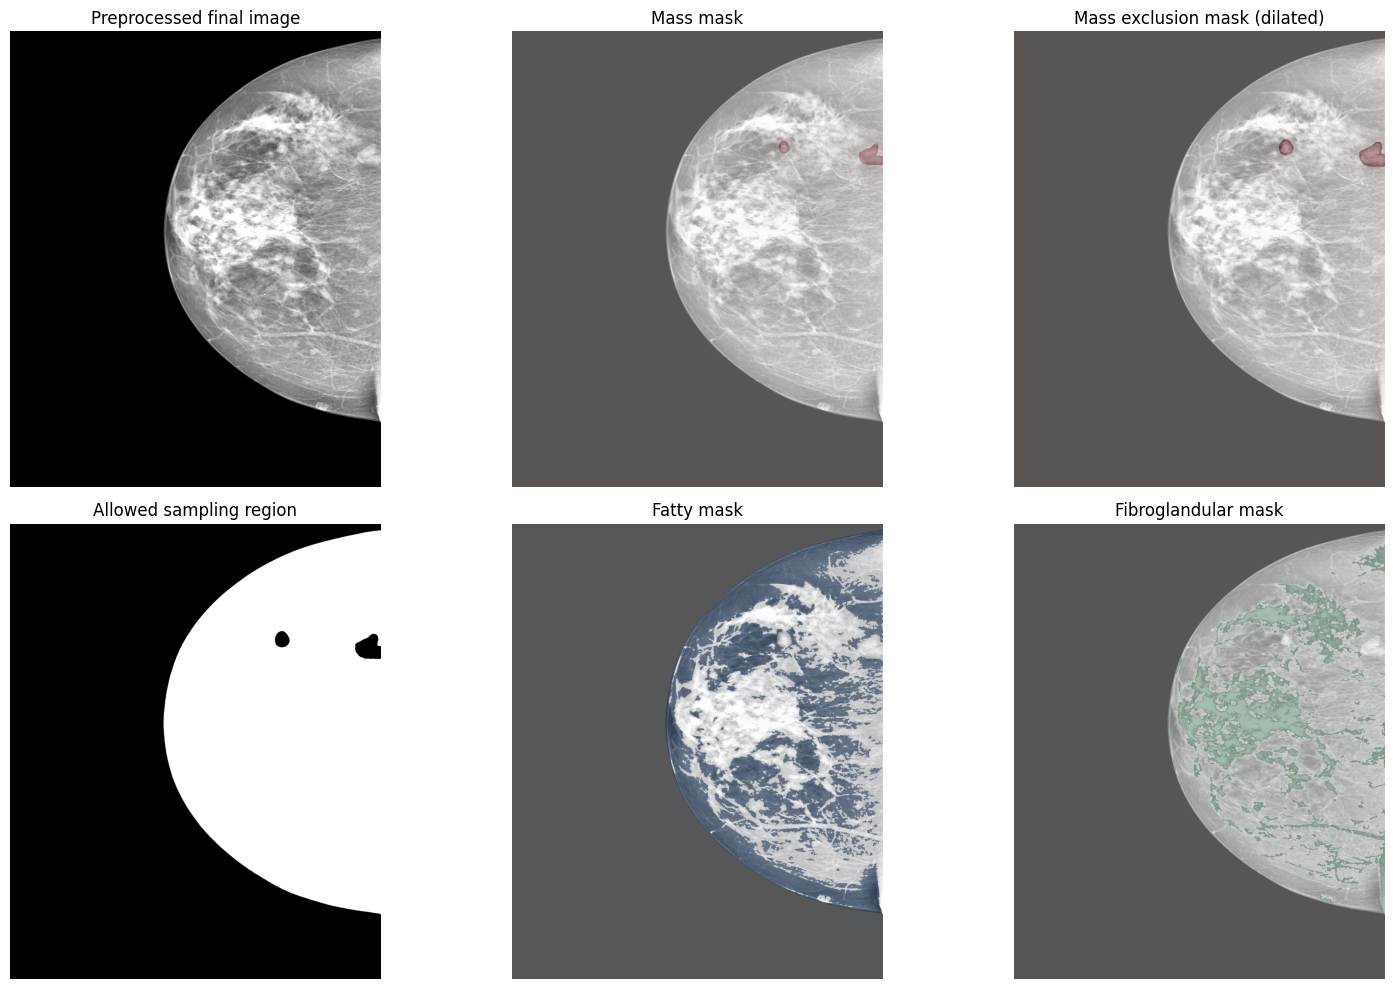

In [8]:
# Pick one example case that has all needed files
sample_id = eligible_ids[0]

img = np.load(final_index[sample_id]).astype(np.float32)
breast_mask = np.load(bmask_index[sample_id]).astype(bool)
pect_mask = np.load(pmask_index[sample_id]).astype(bool) if sample_id in pmask_index else np.zeros_like(breast_mask, dtype=bool)

mass_mask = build_mass_mask(sample_id, img.shape)
mass_excl = dilate_mask(mass_mask, radius=16)

allowed_mask = breast_mask & (~pect_mask) & (~mass_excl)
fatty_mask, fibro_mask, thr = split_fatty_vs_fibro(img, allowed_mask, gap=0.03)

print("sample_id:", sample_id)
print("image shape:", img.shape)
print("mass pixels:", int(mass_mask.sum()))
print("allowed pixels:", int(allowed_mask.sum()))
print("threshold:", thr)

plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Preprocessed final image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(img, cmap="gray")
plt.imshow(mass_mask, alpha=0.35, cmap="Reds")
plt.title("Mass mask")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(img, cmap="gray")
plt.imshow(mass_excl, alpha=0.35, cmap="Reds")
plt.title("Mass exclusion mask (dilated)")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(allowed_mask, cmap="gray")
plt.title("Allowed sampling region")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(img, cmap="gray")
plt.imshow(fatty_mask, alpha=0.35, cmap="Blues")
plt.title("Fatty mask")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(img, cmap="gray")
plt.imshow(fibro_mask, alpha=0.35, cmap="Greens")
plt.title("Fibroglandular mask")
plt.axis("off")

plt.tight_layout()
plt.show()

## 8. Sampler test — accepted patches on one image

Before committing to the full ~4-minute batch save, run the sampler on one image and visualise the actually-accepted patches. Four fatty + four fibroglandular attempts per image, with the same `min_target_frac=0.65` and `forbid_any_overlap=True` constraints that the batch loop uses. Two plots: (1) a zoomed view of the breast with the mass, the exclusion margin and the accepted bounding boxes overlaid, and (2) the eight resized 224×224 patches themselves. If the per-class patches don't look visually distinct here, no point running the full batch.


In [ ]:
# ---------------------------------
# Cell 4: Test sampler on one image
# ---------------------------------

sample_id = eligible_ids[0]

img = np.load(final_index[sample_id]).astype(np.float32)
breast_mask = np.load(bmask_index[sample_id]).astype(bool)
pect_mask = np.load(pmask_index[sample_id]).astype(bool) if sample_id in pmask_index else np.zeros_like(breast_mask, dtype=bool)

# More conservative exclusion around the mass
MASS_DILATION_RADIUS = 24

mass_mask = build_mass_mask(sample_id, img.shape)
mass_excl = dilate_mask(mass_mask, radius=MASS_DILATION_RADIUS)

allowed_mask = breast_mask & (~pect_mask) & (~mass_excl)
fatty_mask, fibro_mask, thr = split_fatty_vs_fibro(img, allowed_mask, gap=0.03)

patch_sizes = make_relative_patch_sizes(
    allowed_mask,
    fracs=(0.14, 0.18, 0.22, 0.26, 0.30),
    min_px=160,
    max_px=512
)

print("sample_id:", sample_id)
print("image shape:", img.shape)
print("mass pixels:", int(mass_mask.sum()))
print("excluded mass pixels:", int(mass_excl.sum()))
print("allowed pixels:", int(allowed_mask.sum()))
print("threshold:", thr)
print("patch sizes being tested:", patch_sizes)

used_boxes_all = []
fatty_examples = []
fibro_examples = []

# sample fatty patches
for _ in range(4):
    s = sample_one_patch(
        img01=img,
        allowed_mask=allowed_mask,
        target_mask=fatty_mask,
        used_boxes=used_boxes_all,
        sizes=patch_sizes,
        min_target_frac=0.65,
        rng=RNG,
        forbid_any_overlap=True,
        require_full_containment=True,
        max_tries=800,
    )
    if s is not None:
        used_boxes_all.append((s["y0"], s["y1"], s["x0"], s["x1"]))
        fatty_examples.append(s)

# sample fibroglandular patches
for _ in range(4):
    s = sample_one_patch(
        img01=img,
        allowed_mask=allowed_mask,
        target_mask=fibro_mask,
        used_boxes=used_boxes_all,
        sizes=patch_sizes,
        min_target_frac=0.65,
        rng=RNG,
        forbid_any_overlap=True,
        require_full_containment=True,
        max_tries=800,
    )
    if s is not None:
        used_boxes_all.append((s["y0"], s["y1"], s["x0"], s["x1"]))
        fibro_examples.append(s)

# ---------------------------------
# Plot 1: zoomed source image + mass + exclusion margin + boxes
# ---------------------------------
bbox = get_bbox_from_mask(breast_mask)
y0b, y1b, x0b, x1b = bbox
pad = 80

yy0 = max(0, y0b - pad)
yy1 = min(img.shape[0], y1b + pad)
xx0 = max(0, x0b - pad)
xx1 = min(img.shape[1], x1b + pad)

plt.figure(figsize=(9, 9))
plt.imshow(img, cmap="gray")

# True mass highlighted in red
plt.imshow(np.ma.masked_where(~mass_mask, mass_mask), cmap="Reds", alpha=0.35)

# Exclusion margin outline in orange dashed
mass_excl_contours, _ = cv2.findContours(
    mass_excl.astype(np.uint8),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)
for cnt in mass_excl_contours:
    cnt = cnt.squeeze()
    if cnt.ndim == 2 and len(cnt) >= 3:
        plt.plot(cnt[:, 0], cnt[:, 1], color="orange", linewidth=2, linestyle="--")

# fatty boxes
for s in fatty_examples:
    rect = plt.Rectangle(
        (s["x0"], s["y0"]),
        s["x1"] - s["x0"] + 1,
        s["y1"] - s["y0"] + 1,
        fill=False,
        edgecolor="cyan",
        linewidth=2.5
    )
    plt.gca().add_patch(rect)

# fibroglandular boxes
for s in fibro_examples:
    rect = plt.Rectangle(
        (s["x0"], s["y0"]),
        s["x1"] - s["x0"] + 1,
        s["y1"] - s["y0"] + 1,
        fill=False,
        edgecolor="lime",
        linewidth=2.5
    )
    plt.gca().add_patch(rect)

plt.xlim(xx0, xx1)
plt.ylim(yy1, yy0)

# Proper legend box (replaces the old descriptive title so the figure reads
# cleanly in the report; the LaTeX caption carries the explanation). The lesion
# itself is conveyed by its dilated exclusion margin, so it needs no separate key.
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color="orange", lw=2, linestyle="--", label="Excluded margin (mass)"),
    Line2D([0], [0], color="cyan", lw=2.5, label="Fatty patch"),
    Line2D([0], [0], color="lime", lw=2.5, label="Fibroglandular patch"),
]
plt.legend(handles=legend_handles, loc="upper right", fontsize=10, framealpha=0.9)
plt.axis("off")

# Save a clean copy for the report (Figure: background-patch sampling).
REPORT_FIG_DIR = Path("../data/outputs/report_figures")
REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(REPORT_FIG_DIR / "patch_sampling_example.png", dpi=200, bbox_inches="tight")

plt.show()

# ---------------------------------
# Plot 2: show actual resized patches
# ---------------------------------
all_examples = [("fatty", x) for x in fatty_examples] + [("fibroglandular", x) for x in fibro_examples]

plt.figure(figsize=(14, 6))
for i, (label, s) in enumerate(all_examples[:8], start=1):
    plt.subplot(2, 4, i)
    plt.imshow(s["patch"], cmap="gray")
    plt.title(
        f"{label}\n"
        f"size={s['orig_size']}, tf={s['target_frac']:.2f}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

print(f"fatty patches accepted: {len(fatty_examples)}")
print(f"fibroglandular patches accepted: {len(fibro_examples)}")
print(f"total accepted patches: {len(fatty_examples) + len(fibro_examples)}")


## 9. Batch extraction with ACR-guided filtering

The main loop. Iterates every one of the 343 eligible image_ids, applies the ACR filter (Section 5 table) to decide which classes that image is allowed to contribute, and runs the sampler up to `MAX_PER_IMAGE_PER_CLASS = 3` times per class. Patches are saved into `data/outputs/background_patches/{fatty,fibroglandular}/<file_id>_<class>_<idx>.npy` (+ `.png` preview), and a single `patches_index.csv` records every patch with its source paths, ACR, intensity stats and bounding-box coordinates. Runtime is roughly 3–4 minutes on a laptop; the loop is deterministic given `SEED = 34`.


In [10]:
# ---------------------------------
# Cell 5: Batch extraction and save (ACR-guided, no early stopping)
# ---------------------------------

MAX_PER_IMAGE_PER_CLASS = 3
STRICT_GAP = 0.03
MASS_DILATION_RADIUS = 24

# ACR-based class eligibility:
# ACR 1 (almost entirely fatty)      -> only sample fatty
# ACR 2 (scattered fibroglandular)   -> sample both
# ACR 3 (heterogeneously dense)      -> sample both
# ACR 4 (extremely dense)            -> only sample fibroglandular
ACR_ALLOWS_FATTY = {1, 2, 3}
ACR_ALLOWS_FIBRO = {2, 3, 4}

records = []
counts = {"fatty": 0, "fibroglandular": 0}
skipped_by_acr = {"fatty": 0, "fibroglandular": 0}

# Clear old patches for a clean rerun
for folder in [PATCH_BG_FATTY, PATCH_BG_FIBRO]:
    for fp in folder.glob("*.npy"):
        fp.unlink()
    for fp in folder.glob("*.png"):
        fp.unlink()

for file_id in tqdm(eligible_ids, desc="Extracting background patches"):
    img = np.load(final_index[file_id]).astype(np.float32)
    breast_mask = np.load(bmask_index[file_id]).astype(bool)
    pect_mask = (
        np.load(pmask_index[file_id]).astype(bool)
        if file_id in pmask_index
        else np.zeros_like(breast_mask, dtype=bool)
    )

    mass_mask = build_mass_mask(file_id, img.shape)
    if mass_mask.sum() == 0:
        continue

    # Look up ACR density for this image
    if file_id not in image_meta.index:
        continue
    acr = image_meta.loc[file_id, "ACR"]
    acr = int(acr) if pd.notna(acr) else None
    if acr is None:
        continue

    mass_excl = dilate_mask(mass_mask, radius=MASS_DILATION_RADIUS)
    allowed_mask = breast_mask & (~pect_mask) & (~mass_excl)

    if allowed_mask.sum() < 5000:
        continue

    fatty_mask, fibro_mask, thr = split_fatty_vs_fibro(img, allowed_mask, gap=STRICT_GAP)

    patch_sizes = make_relative_patch_sizes(
        allowed_mask,
        fracs=(0.14, 0.18, 0.22, 0.26, 0.30),
        min_px=160,
        max_px=512
    )

    per_image_boxes_all = []

    for label, target_mask, out_dir in [
        ("fatty", fatty_mask, PATCH_BG_FATTY),
        ("fibroglandular", fibro_mask, PATCH_BG_FIBRO),
    ]:
        # ── ACR filter ──────────────────────────────────────────
        if label == "fatty" and acr not in ACR_ALLOWS_FATTY:
            skipped_by_acr["fatty"] += 1
            continue
        if label == "fibroglandular" and acr not in ACR_ALLOWS_FIBRO:
            skipped_by_acr["fibroglandular"] += 1
            continue
        # ────────────────────────────────────────────────────────

        n_added_here = 0

        while n_added_here < MAX_PER_IMAGE_PER_CLASS:
            sampled = sample_one_patch(
                img01=img,
                allowed_mask=allowed_mask,
                target_mask=target_mask,
                used_boxes=per_image_boxes_all,
                sizes=patch_sizes,
                min_target_frac=0.65,
                rng=RNG,
                forbid_any_overlap=True,
                require_full_containment=True,
                max_tries=800,
            )

            if sampled is None:
                break

            box = (sampled["y0"], sampled["y1"], sampled["x0"], sampled["x1"])
            per_image_boxes_all.append(box)

            patch_idx = counts[label]
            out_stem = out_dir / f"{file_id}_{label}_{patch_idx:03d}"

            save_patch_npy_and_png(sampled["patch"], out_stem)

            records.append({
                "file_id": file_id,
                "label": label,
                "acr": acr,
                "patch_npy": str(out_stem.with_suffix(".npy")),
                "patch_png": str(out_stem.with_suffix(".png")),
                "source_final_npy": str(final_index[file_id]),
                "source_breast_mask_npy": str(bmask_index[file_id]),
                "source_pect_mask_npy": str(pmask_index[file_id]) if file_id in pmask_index else None,
                "xml_path": str(xml_index[file_id]),
                "threshold": thr,
                "orig_size": sampled["orig_size"],
                "y0": sampled["y0"],
                "y1": sampled["y1"],
                "x0": sampled["x0"],
                "x1": sampled["x1"],
                "allowed_frac": sampled["allowed_frac"],
                "target_frac": sampled["target_frac"],
                "mean_intensity": sampled["mean_intensity"],
                "std_intensity": sampled["std_intensity"],
            })

            counts[label] += 1
            n_added_here += 1

manifest_bg = pd.DataFrame(records)
manifest_path = PATCH_ROOT / "patches_index.csv"
manifest_bg.to_csv(manifest_path, index=False)

print("Saved manifest:", manifest_path)
print("Patch counts:", counts)
print(f"Skipped by ACR filter — fatty from ACR 4: {skipped_by_acr['fatty']}, fibro from ACR 1: {skipped_by_acr['fibroglandular']}")
display(manifest_bg.head())


Extracting background patches: 100%|██████████| 343/343 [03:43<00:00,  1.53it/s]

Saved manifest: ../data/outputs/background_patches/patches_index.csv
Patch counts: {'fatty': 251, 'fibroglandular': 183}
Skipped by ACR filter — fatty from ACR 4: 8, fibro from ACR 1: 42


,file_id,label,acr,patch_npy,patch_png,source_final_npy,source_breast_mask_npy,source_pect_mask_npy,xml_path,threshold,orig_size,y0,y1,x0,x1,allowed_frac,target_frac,mean_intensity,std_intensity
0,20586908,fatty,2,../data/outputs/background_patches/fatty/20586...,../data/outputs/background_patches/fatty/20586...,../data/outputs/preprocessed/final/20586908_6c...,../data/outputs/preprocessed/breast_mask/20586...,../data/outputs/preprocessed/pect_mask/2058690...,../data/raw/kaggle_inbreast/AllXML/20586908.xml,0.681258,273,1135,1407,1804,2076,1.0,0.748849,0.571869,0.126487
1,20586908,fatty,2,../data/outputs/background_patches/fatty/20586...,../data/outputs/background_patches/fatty/20586...,../data/outputs/preprocessed/final/20586908_6c...,../data/outputs/preprocessed/breast_mask/20586...,../data/outputs/preprocessed/pect_mask/2058690...,../data/raw/kaggle_inbreast/AllXML/20586908.xml,0.681258,351,1159,1509,2530,2880,1.0,0.658777,0.605455,0.102193
2,20586908,fatty,2,../data/outputs/background_patches/fatty/20586...,../data/outputs/background_patches/fatty/20586...,../data/outputs/preprocessed/final/20586908_6c...,../data/outputs/preprocessed/breast_mask/20586...,../data/outputs/preprocessed/pect_mask/2058690...,../data/raw/kaggle_inbreast/AllXML/20586908.xml,0.681258,351,2149,2499,1915,2265,1.0,0.754263,0.579174,0.092580
3,20586908,fibroglandular,2,../data/outputs/background_patches/fibroglandu...,../data/outputs/background_patches/fibroglandu...,../data/outputs/preprocessed/final/20586908_6c...,../data/outputs/preprocessed/breast_mask/20586...,../data/outputs/preprocessed/pect_mask/2058690...,../data/raw/kaggle_inbreast/AllXML/20586908.xml,0.681258,273,1446,1718,1853,2125,1.0,0.783936,0.846359,0.136011
4,20586908,fibroglandular,2,../data/outputs/background_patches/fibroglandu...,../data/outputs/background_patches/fibroglandu...,../data/outputs/preprocessed/final/20586908_6c...,../data/outputs/preprocessed/breast_mask/20586...,../data/outputs/preprocessed/pect_mask/2058690...,../data/raw/kaggle_inbreast/AllXML/20586908.xml,0.681258,351,1797,2147,1862,2212,1.0,0.714726,0.804286,0.147768


### 9.1 What was extracted

- **251 fatty + 183 fibroglandular = 434 background patches**.
- 343 eligible image_ids processed; roughly 100 distinct images contribute (varies by ACR and whether Otsu produced enough qualifying pixels).
- **ACR filter skip counts** are recorded in `skipped_by_acr`: about 8 fatty-attempts skipped from ACR-4 breasts, about 42 fibroglandular-attempts skipped from ACR-1 breasts.
- **Comparison with the paper:** the paper reports 397 patches (210 fatty + 187 fibroglandular). The differences come from (a) our ACR-guided sampling (the paper does not document a density-aware filter), and (b) the absence of a hard-coded target count — we process all eligible images instead of stopping at a fixed budget.

The 434 patches are the input to Steps 2.1 / 2.2 / 2.3 / 2.4 for the **fatty-vs-fibroglandular tissue task**. They are kept separate from the mass patches by construction (mass region is excluded from the sampling area, and the train/test split is image-level so the same `file_id` can never contribute to both the mass and tissue tasks within a fold).


## 10. Summary and QC

A final read-back of the manifest with per-class counts, per-ACR breakdowns, patch-size distribution, allowed-fraction and target-fraction summaries, and a 12-patch random visual sample. This is the cell to inspect if you want to confirm what was actually saved.


Final counts from manifest:


label
fatty             251
fibroglandular    183
Name: count, dtype: int64


Unique source images used per class:


label
fatty             91
fibroglandular    63
Name: file_id, dtype: int64


=== ACR breakdown: patches by label and ACR ===


...

count    434.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: allowed_frac, dtype: float64


Target fraction summary:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
fatty,251.0,0.756834,0.085293,0.651190,0.685169,0.740101,0.817142,1.0
fibroglandular,183.0,0.761298,0.092157,0.652813,0.683873,0.739982,0.818046,1.0



Intensity summary:


mean_intensity                               std_intensity  \
                         mean       std       min       max          mean   
label                                                                       
fatty                0.559337  0.054856  0.317952  0.690697      0.102342   
fibroglandular       0.791549  0.059491  0.613896  0.952221      0.120972   

                                              
                     std       min       max  
label                                         
fatty           0.031983  0.041377  0.221989  
fibroglandular  0.030826  0.054897  0.239832

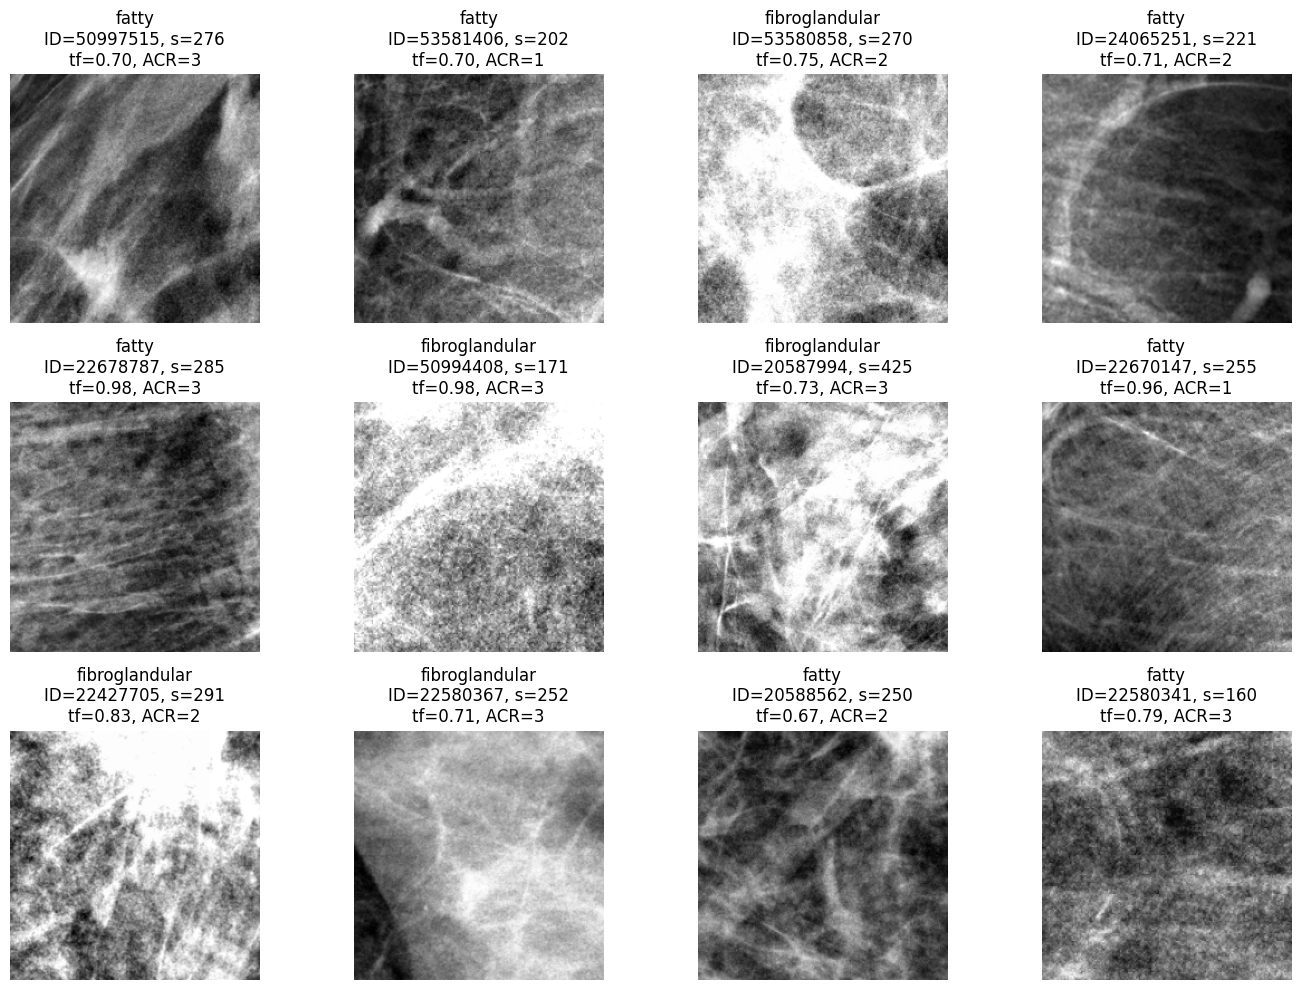

In [11]:
# ---------------------------------
# Cell 6: Summary and QC
# ---------------------------------

print("Final counts from manifest:")
display(manifest_bg["label"].value_counts())

print("\nUnique source images used per class:")
display(manifest_bg.groupby("label")["file_id"].nunique())

print("\n=== ACR breakdown: patches by label and ACR ===")
if "acr" in manifest_bg.columns:
    ct = manifest_bg.groupby(["label", "acr"]).size().unstack(fill_value=0)
    display(ct)
    print("\nUnique images per label per ACR:")
    display(manifest_bg.groupby(["label", "acr"])["file_id"].nunique().unstack(fill_value=0))
else:
    print("(no ACR column in manifest)")

print("\nPatch size distribution:")
display(manifest_bg["orig_size"].value_counts().sort_index())

print("\nAllowed fraction summary:")
display(manifest_bg["allowed_frac"].describe())

print("\nTarget fraction summary:")
display(manifest_bg.groupby("label")["target_frac"].describe())

print("\nIntensity summary:")
display(
    manifest_bg.groupby("label")[["mean_intensity", "std_intensity"]]
    .agg(["mean", "std", "min", "max"])
)

# Show a few random saved patches
if len(manifest_bg) > 0:
    show_df = manifest_bg.sample(min(12, len(manifest_bg)), random_state=SEED).reset_index(drop=True)

    plt.figure(figsize=(14, 10))
    for i, row in show_df.iterrows():
        patch = np.load(row["patch_npy"])
        plt.subplot(3, 4, i + 1)
        plt.imshow(patch, cmap="gray")
        acr_str = f", ACR={int(row['acr'])}" if "acr" in row and pd.notna(row["acr"]) else ""
        plt.title(
            f"{row['label']}\n"
            f"ID={row['file_id']}, s={row['orig_size']}\n"
            f"tf={row['target_frac']:.2f}{acr_str}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("manifest_bg is empty — no patches were saved.")


## 11. Summary

What this notebook produces:

- `data/outputs/background_patches/fatty/` — **251 patches** (`.npy` + `.png` previews) drawn from ACR-1/2/3 breasts.
- `data/outputs/background_patches/fibroglandular/` — **183 patches** drawn from ACR-2/3/4 breasts.
- `data/outputs/background_patches/patches_index.csv` — one row per patch with `file_id`, `label`, `acr`, source paths, original patch size (in pixels of the source DICOM), bounding-box coordinates, allowed-fraction, target-class fraction, and intensity statistics.

What this notebook does **not** do:

- It does not classify anything — the 434 patches go to Steps 2.1/2.2/2.3/2.4 as the input to the fatty-vs-fibroglandular task.
- It does not extract mass patches — that is Step 1.2.
- It does not change the preprocessing — every patch is cropped from the already-preprocessed `data/outputs/preprocessed/final/*.npy` arrays.

Reproducibility:

- `SEED = 34` drives the single `np.random.default_rng(SEED)` generator used by the sampler. The same patches are produced on every run.
- The batch save is otherwise deterministic — XML order is sorted, ACR lookups are dict-keyed, the Otsu threshold per image is data-driven.

Downstream caveats:

- The paper's count is **397 (210 fatty + 187 fibroglandular)**; ours is **434 (251 + 183)**. The difference is explained by our ACR-guided sampling (no density-aware filter is documented in the paper) and by not enforcing a hard-coded target count.
- `manifest["acr"]` is an integer for downstream stratification; if you want the raw BI-RADS string for a patch (rare), re-join against `data/outputs/inbreast_index.csv` from Step 0.2.
